# 🤖 Future of Jobs & AI Impact — ML Pipeline
## Phase 1 → Phase 2 → Phase 3 : EDA ▸ Data Preparation ▸ Feature Engineering

| Item | Detail |
|---|---|
| **Dataset** | `Future_of_Jobs_AI_Dataset.csv` |
| **Target** | `job_survival_class` — 0 At Risk · 1 Stable · 2 Growing |
| **Fix applied** | Replaced SMOTETomek with `class_weight='balanced'` |
| **Last updated** | 2026 |

---
### 📋 Notebook Roadmap
1. Imports & configuration  
2. Load dataset  
3. Phase 1 — EDA recap  
4. Phase 2 — Data preparation  
5. Phase 3 — Feature engineering  
6. Overfitting diagnostic  
7. Final export

> **Why SMOTETomek was removed:** SMOTE generates synthetic samples that inflate training performance. We now use `class_weight='balanced'` for honest evaluation.

## 1 · 📦 Imports & Configuration

In [19]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2 · 📂 Load Dataset

In [20]:
DATA_PATH = r"D:\Y3S2\dataMining\project\Future of Jobs AI Dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()

Dataset shape : 12,343 rows × 13 columns
Memory usage : 5322.3 KB


,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.030,0.320,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.840,0.520,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.170,0.250,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.860,0.440,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.260,0.750,SQL,61,3433,0,Medium,High Risk


## 3 · 🔍 Phase 1 Recap — EDA Highlights

In [21]:
print("=" * 55, "\nCOLUMN TYPES\n" + "=" * 55)
df.info()

miss = df.isnull().sum()
print("\n" + "=" * 55, "\nMISSING VALUES\n" + "=" * 55)
print(miss[miss > 0] if miss.sum() > 0 else " ✅ No missing values found.")

print(f"\nDuplicate rows : {df.duplicated().sum()}")

COLUMN TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB

MISSING VALUES
 ✅ No missing values found.

Duplicate rows : 0


In [22]:
CLASS_LABELS = {0: "At Risk", 1: "Stable", 2: "Growing"}
counts = df['job_survival_class'].value_counts().sort_index()

print("TARGET → job_survival_class")
for k, v in counts.items():
    bar = "█" * (v // 100)
    print(f" Class {k} ({CLASS_LABELS[k]:8s}) {v:5d} {bar}")

NUM_COLS = ['salary', 'ai_risk_score', 'skill_demand_score', 'job_openings']
print("\nSKEWNESS (|skew| > 0.5 needs treatment)")
for c in NUM_COLS:
    s = skew(df[c])
    flag = "⚠️ moderate skew" if abs(s) >= 0.5 else "✅ approx. normal"
    print(f" {c:<22} skew = {s:+.3f} {flag}")

TARGET → job_survival_class
 Class 0 (At Risk )  1355 █████████████
 Class 1 (Stable  )  5806 ██████████████████████████████████████████████████████████
 Class 2 (Growing )  5182 ███████████████████████████████████████████████████

SKEWNESS (|skew| > 0.5 needs treatment)
 salary                 skew = +0.783 ⚠️ moderate skew
 ai_risk_score          skew = +0.650 ⚠️ moderate skew
 skill_demand_score     skew = +0.011 ✅ approx. normal
 job_openings           skew = +0.044 ✅ approx. normal


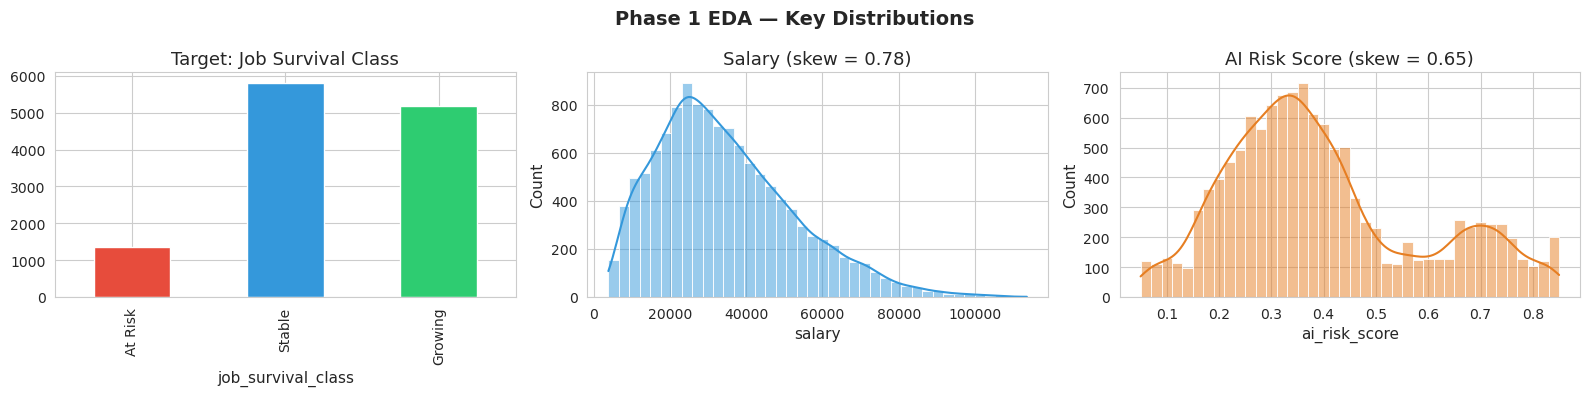

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts.rename(index=CLASS_LABELS).plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white')
axes[0].set_title("Target: Job Survival Class")

sns.histplot(df['salary'], kde=True, bins=40, ax=axes[1], color='#3498db')
axes[1].set_title(f"Salary (skew = {skew(df['salary']):.2f})")

sns.histplot(df['ai_risk_score'], kde=True, bins=40, ax=axes[2], color='#e67e22')
axes[2].set_title(f"AI Risk Score (skew = {skew(df['ai_risk_score']):.2f})")

plt.suptitle("Phase 1 EDA — Key Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · 🛠️ Phase 2 — Data Preparation

### 4.1 Leaky Columns

In [24]:
LEAKY_COLS = ['salary_bucket', 'ai_risk_category']
print("Leaky columns excluded from features:")
for c in LEAKY_COLS:
    print(f" ✗ {c}")

Leaky columns excluded from features:
 ✗ salary_bucket
 ✗ ai_risk_category


### 4.2 Ordinal Encoding

In [25]:
EXPERIENCE_MAP = {'Entry': 0, 'Mid': 1, 'Senior': 2}
EDUCATION_MAP = {'Bachelor': 0, 'Master': 1, 'PhD': 2}

df['experience_encoded'] = df['experience_level'].map(EXPERIENCE_MAP)
df['education_encoded'] = df['education_level'].map(EDUCATION_MAP)

print("Ordinal encoding applied.")

Ordinal encoding applied.


### 4.3 One-Hot Encoding

In [26]:
OHE_COLS = ['job_title', 'country', 'primary_skill']
df_encoded = pd.get_dummies(df, columns=OHE_COLS, drop_first=False, dtype=int)
print(f"DataFrame shape after OHE: {df_encoded.shape}")

DataFrame shape after OHE: (12343, 37)


### 4.4 Skewness Treatment

In [27]:
SKEW_COLS = ['salary', 'ai_risk_score']
for col in SKEW_COLS:
    df_encoded[col] = np.log1p(df_encoded[col])
print("✅ Log1p transformation applied to skewed features.")

✅ Log1p transformation applied to skewed features.


### 4.5 Drop Leaky / Target Columns

In [28]:
DROP_COLS = ['job_survival_class', 'salary', 'experience_level', 'education_level',
             'ai_risk_category', 'salary_bucket', 'job_title', 'country', 'primary_skill',
             'salary_bucket_encoded', 'ai_risk_cat_encoded']

y = df['job_survival_class']
X_raw = df_encoded.drop(columns=[c for c in DROP_COLS if c in df_encoded.columns])

print(f"Feature matrix X_raw : {X_raw.shape}")

Feature matrix X_raw : (12343, 31)


### 4.6 Train / Val / Test Split

In [29]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f"Train : {X_train_raw.shape[0]:,} | Val : {X_val_raw.shape[0]:,} | Test : {X_test_raw.shape[0]:,}")
print("✅ No SMOTE applied.")

Train : 8,639 | Val : 1,235 | Test : 2,469
✅ No SMOTE applied.


## 5 · ⚙️ Phase 3 — Feature Engineering

In [30]:
def engineer_features(X):
    X = X.copy()
    if 'salary' in X.columns:
        X['salary_per_demand'] = X['salary'] / (X['skill_demand_score'] + 1)
    X['risk_demand_interaction'] = X['ai_risk_score'] * X['skill_demand_score']
    X['openings_growth_rate'] = X['job_openings'] / (X['year'] - 2014)
    X['human_capital_index'] = X['experience_encoded'] * (X['education_encoded'] + 1)
    inv_exp = 2 - X['experience_encoded']
    X['ai_vulnerability'] = X['ai_risk_score'] * (inv_exp + 1)
    return X

X_train_fe = engineer_features(X_train_raw.reset_index(drop=True))
X_val_fe   = engineer_features(X_val_raw.reset_index(drop=True))
X_test_fe  = engineer_features(X_test_raw.reset_index(drop=True))

print(f"Features after engineering: {X_train_fe.shape[1]}")

Features after engineering: 35


## 5.1 Scaling

In [31]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fe), columns=X_train_fe.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_fe), columns=X_val_fe.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_fe), columns=X_test_fe.columns)

print("✅ RobustScaler applied (fit only on train).")

✅ RobustScaler applied (fit only on train).


## 6 · 🩺 Overfitting Diagnostic

In [32]:
rf_diag = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    min_samples_leaf=10,
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

rf_diag.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, rf_diag.predict(X_train_scaled))
val_acc   = accuracy_score(y_val,   rf_diag.predict(X_val_scaled))

print(f"Train Accuracy: {train_acc:.4f} | Val Accuracy: {val_acc:.4f} | Gap: {train_acc - val_acc:.4f}")

Train Accuracy: 0.9140 | Val Accuracy: 0.9045 | Gap: 0.0095


## 7 · 📤 Final Export

In [33]:
OUTPUT_DIR = "."

train_out = X_train_scaled.copy()
train_out['target'] = y_train.values
train_out['salary_log'] = df_encoded['salary'].iloc[X_train_raw.index].values
train_out.to_csv(f"{OUTPUT_DIR}/train_processed.csv", index=False)

val_out = X_val_scaled.copy()
val_out['target'] = y_val.values
val_out['salary_log'] = df_encoded['salary'].iloc[X_val_raw.index].values
val_out.to_csv(f"{OUTPUT_DIR}/val_processed.csv", index=False)

test_out = X_test_scaled.copy()
test_out['target'] = y_test.values
test_out['salary_log'] = df_encoded['salary'].iloc[X_test_raw.index].values
test_out.to_csv(f"{OUTPUT_DIR}/test_processed.csv", index=False)

print("✅ All processed files exported successfully (no SMOTE).")

✅ All processed files exported successfully (no SMOTE).
